# BCS 能隙方程：从理论到数值验证

**学习目标**：推导中的符号能对应到程序；独立验证零温解与弱耦合极限；看懂温度扫描和误差。

这是各向同性、常态密度、有限截止的平均场模型，不是某种真实材料的预测，也不是原论文图表复现。
先阅读同目录的《BCS理论与计算入门教程》。预计第一次学习需要 2–4 小时。

操作：从本目录启动 Jupyter，按顺序执行。修改参数后，从头重新运行，避免残留状态。

## 1. 先统一单位和归一化

$g=N_{\mathrm{single\,spin}}(0)V>0$；$d=\Delta/E_c$；$t=k_BT/E_c$。

程序里的 temperature 是无量纲 $t$，不是 K；$N(0)$ 使用**单自旋**常态密度。
求解的非零配对分支满足
$$\frac1g=\int_0^1\frac{\tanh[\sqrt{x^2+d^2}/(2t)]}{\sqrt{x^2+d^2}}dx.$$
不要再人为增加一个自旋因子 2。

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from bcs import BCSModel, dynes_dos, to_kelvin
print("Python:", sys.version.split()[0])
g = 0.30
cutoff_mev = 20.0  # Assumed teaching scale, not obtained from aluminum DFT.
model = BCSModel(g)
d0 = model.delta0_exact
tc = model.critical_temperature()
print(f"d0 = {d0:.12g}, tc = {tc:.12g}")
print(f"gap ratio = {2*d0/tc:.9f}")
print(f"Assumed cutoff gives Tc = {to_kelvin(tc, cutoff_mev):.6f} K")

Python: 3.12.4
d0 = 0.0714389022562, tc = 0.0404495251909
gap ratio = 3.532249237
Assumed cutoff gives Tc = 9.387945 K


## 2. 用一个独立积分验证零温解

在 $T=0$，$\tanh \to1$，得到
$\operatorname{asinh}(1/d_0)=1/g$，所以 $d_0=1/\sinh(1/g)$。

下面不调用模型内部的零温解析积分，而是重新数值积分，减少“同一个公式验证自己”的风险。
**先猜一猜**：残差应为 $10^{-2}$，还是接近数值精度？

In [2]:
from scipy.integrate import quad
independent_integral, error_estimate = quad(
    lambda x: 1 / np.sqrt(x*x + d0*d0), 0, 1,
    epsabs=1e-11, epsrel=1e-11
)
residual0 = independent_integral - 1/g
print("Independent zero-T residual:", residual0)
assert abs(residual0) < 1e-9

Independent zero-T residual: 0.0


## 3. 临界温度不是从经验曲线拟合出来的

对连续转变，让 $d\to0$，求线性化方程。
正温度时积分核在 $x=0$ 的极限是 $1/(2t)$，不是发散。

检查：$t<t_c$ 时零能隙的配对残差为正；$t>t_c$ 时为负。

In [3]:
for factor in [0.8, 1.0, 1.2]:
    print(f"T/Tc={factor:.1f}, F(0,t)={model.residual(0, factor*tc): .6e}")
assert model.residual(0, 0.8*tc) > 0
assert abs(model.residual(0, tc)) < 1e-9
assert model.residual(0, 1.2*tc) < 0

T/Tc=0.8, F(0,t)= 2.231436e-01
T/Tc=1.0, F(0,t)= 0.000000e+00
T/Tc=1.2, F(0,t)=-1.823216e-01


## 4. 温度扫描：先预测，再画图

配对能隙应随温度下降，并在 $T_c$ 消失。原始未除以 $\Delta$ 的方程始终有零解；
这里只追踪 $T<T_c$ 的非零分支，然后在 $T\ge T_c$ 返回正常态零解。

低温平台的相邻点可能在浮点精度内相等，不要求每一步严格下降。

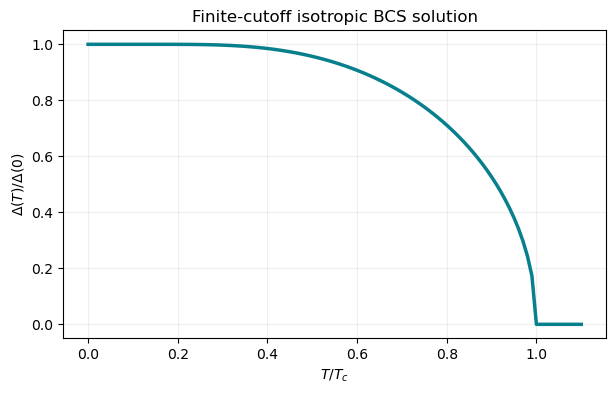

In [4]:
reduced_t = np.linspace(0, 1.10, 111)
gaps = np.array([model.gap(u*tc, tc=tc) for u in reduced_t])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(reduced_t, gaps/d0, color="#087F8C", lw=2.5)
ax.set(xlabel=r"$T/T_c$", ylabel=r"$\Delta(T)/\Delta(0)$",
       title="Finite-cutoff isotropic BCS solution")
ax.grid(alpha=0.2)
plt.show()
assert np.all(np.diff(gaps) <= 1e-12)
assert np.all(gaps[reduced_t >= 1] == 0)

## 5. 图像好看不代表方程解对了

每个非零解都代回方程。正常态点不参与这个残差判断，因为前面的方程已经除过 $\Delta$。
自动化脚本还会比较积分容差 $10^{-6},10^{-8},10^{-10}$，详细结果见 validation.json。

In [5]:
residuals = np.array([
    model.residual(d, u*tc) for d, u in zip(gaps, reduced_t) if d > 0
])
print("Maximum nonzero-branch residual:", np.max(np.abs(residuals)))
assert np.max(np.abs(residuals)) < 1e-8
for tol in [1e-6, 1e-8, 1e-10]:
    print(tol, BCSModel(g, tol, tol).critical_temperature())

Maximum nonzero-branch residual: 3.872457909892546e-13
1e-06 0.04044952519089008
1e-08 0.04044952519089008
1e-10 0.040449525190890075


## 6. 耦合扫描与弱耦合极限

$t_c\simeq(2e^\gamma/\pi)e^{-1/g}$，
$2d_0/t_c\to2\pi/e^\gamma\simeq3.527754$。

有限截止模型在 $g=0.30$ 的结果约 3.532249，并非必须精确等于 3.527754。
增大 $g$ 的这个简单模型**不是**强耦合 Eliashberg 理论。

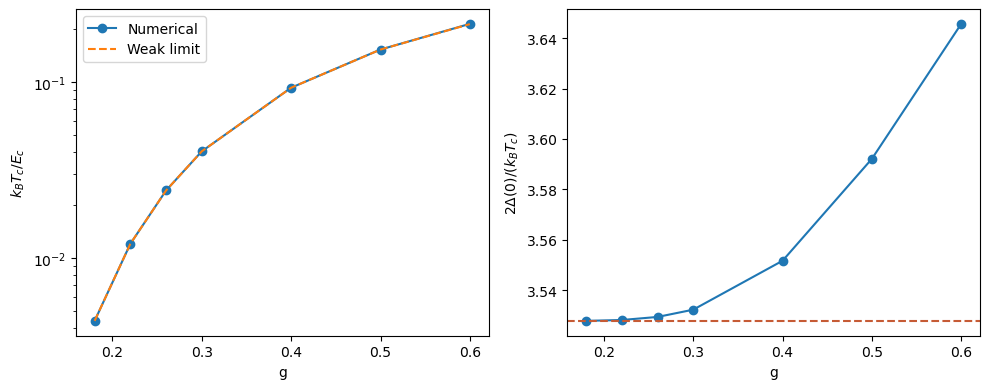

[[0.18       0.00438344 3.5278067 ]
 [0.22       0.01203638 3.52815155]
 [0.26       0.02422135 3.52936451]
 [0.3        0.04044953 3.53224924]
 [0.4        0.09307373 3.55167191]
 [0.5        0.15351347 3.59213512]
 [0.6        0.21489726 3.6457015 ]]


In [6]:
couplings = np.array([0.18, 0.22, 0.26, 0.30, 0.40, 0.50, 0.60])
numerical_tc = np.array([BCSModel(v).critical_temperature() for v in couplings])
weak_tc = 2*np.exp(np.euler_gamma)/np.pi * np.exp(-1/couplings)
ratios = np.array([2*BCSModel(v).delta0_exact/t
                   for v, t in zip(couplings, numerical_tc)])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].semilogy(couplings, numerical_tc, "o-", label="Numerical")
axes[0].semilogy(couplings, weak_tc, "--", label="Weak limit")
axes[0].set(xlabel="g", ylabel=r"$k_BT_c/E_c$")
axes[0].legend()
axes[1].plot(couplings, ratios, "o-")
axes[1].axhline(2*np.pi/np.exp(np.euler_gamma), ls="--", color="#C65B35")
axes[1].set(xlabel="g", ylabel=r"$2\Delta(0)/(k_BT_c)$")
plt.tight_layout()
plt.show()
print(np.column_stack([couplings, numerical_tc, ratios]))

## 7. 态密度只是一种示意观测量

Dynes 展宽（phenomenological broadening）把 $E$ 替换成 $E+i\eta$，使理想相干峰不再发散。
这里使用粒子–空穴对称的常态密度近似；$\eta$ 不是从第一性原理得到的寿命，
更不是 DFT 金属展宽 degauss。

练习：把 $\eta/\Delta_0$ 从 0.03 改成 0.01、0.10，预测峰高和能隙内态密度如何变化。

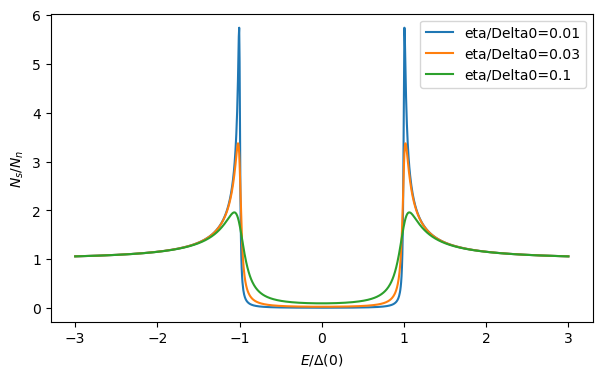

In [7]:
energies = np.linspace(-3*d0, 3*d0, 1201)
fig, ax = plt.subplots(figsize=(7, 4))
for eta_ratio in [0.01, 0.03, 0.10]:
    ax.plot(energies/d0, dynes_dos(energies, d0, eta_ratio*d0),
            label=f"eta/Delta0={eta_ratio}")
ax.set(xlabel=r"$E/\Delta(0)$", ylabel=r"$N_s/N_n$")
ax.legend()
plt.show()

## 8. 练习和参考答案

1. 把 $g$ 改为 0.18，检查能隙比更接近弱耦合极限。答案：偏差减小。
2. 固定 $g$，把 $E_c$ 从 20 改为 40 meV。答案：无量纲曲线不变，K 和 meV 的结果翻倍。
3. 为什么低温曲线几乎水平？答案：热激发被能隙压低，不等于迭代停止。
4. 若想模拟 d 波，是否只改标题？答案：不行，要给出动量依赖相互作用与能隙、重新处理自洽积分和节点态密度。
5. 为什么铝 SCF 算出金属能带，仍没有超导能隙？答案：这里的常态 DFT 未包含本教程的配对自洽问题。

下一步：阅读 ../02_qe_al_smoke/第一性原理与集群入门.md，
区分 SCF、DFPT、EPC、Eliashberg。二维材料还需分清配对温度与相位有序/BKT 温度。

官方资源：MIT OCW 6.763 与 8.514 的教材已按 CC BY-NC-SA 4.0 保存，归属信息见 ../../resources/开放教材与复用说明.md。
BCS 原始论文 DOI：https://doi.org/10.1103/PhysRev.108.1175。